# Exact Hubbard parameters

`bloch_schrodinger.hubbard` computes the Hubbard on-site interaction $U$ for
atoms in a quasi-low-dimensional optical lattice, *without* assuming the
single-band Wannier form.

The usual estimate is the overlap of four lowest-band Wannier functions,

$$U_{\rm Born} = g\int|w(x)|^4dx ,\qquad g_{\rm 1D} = -\frac{2\hbar^2}{m\,a_{\rm 1D}} ,$$

which is linear in the coupling by construction. It is the **leading Born term**
of the true on-site interaction. The exact treatment instead *defines* $U$ by
requiring the Hubbard model to reproduce the exact two-body scattering amplitude
of the lattice as the relative quasi-momentum $p\to0$:

$$T_{\rm exact}^{-1} = g^{-1} - \Pi ,\qquad T_{\rm Hub}^{-1} = U^{-1} - \Pi_{\rm Hub},$$

where the pair propagator $\Pi$ is built in the basis of two-atom
centre-of-mass lattice states, so **all** bands and **all** transverse harmonic
modes are summed over. Matching the imaginary parts (the on-shell density of
states) fixes one factor; $U$ is then read off from the real parts.

This is a validated port of the Mathematica package
`cold-atom-hubbard-parameters` (H. S. Adlong *et al.*).

### Scope

The method factorises the pair problem into independent lattice directions, so
it covers

* a **quasi-1D** lattice (1D lattice + 2D transverse harmonic trap), and
* a **quasi-2D separable square** lattice ($V(x)+V(y)$ + 1D trap along $z$).

A honeycomb or triangular lattice is *not* separable and must not be passed in
directly; see the last section for what to do instead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from bloch_schrodinger.hubbard import (
    V_REC, UnitConverter,
    hubbard_u_quasi1d, hubbard_u_wannier_1d,
    hubbard_u_quasi2d, hubbard_u_wannier_2d_square,
    a1d_inv_from_a3d, log_a2d_inv_from_a3d,
    wannier_profile_1d, wannier_quartic_2d_square,
    matched_square_depth_from_quartic, site_trap_frequency, hopping,
)

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK2, GRID, SURFACE = "#52514e", "#e6e5e1", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "axes.edgecolor": INK2, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlelocation": "left", "axes.titleweight": "600", "axes.titlesize": 11,
    "legend.frameon": False, "lines.linewidth": 2.0, "figure.dpi": 110,
})
print("V_REC =", round(V_REC, 8))

V_REC = 4.9348022


## 1. Units

Everything in the public API is stated in *your* units: you say what the kinetic
coefficient `alpha` is (`H = alpha k^2 + V`) and what the lattice spacing is, and
`UnitConverter` maps to the solver's internal $m=\hbar=d=1$.

The defining identity is that a lattice's own recoil energy must map to
$\pi^2/2$. Lattice depths are quoted **in recoils**, so they are dimensionless
and need no conversion at all.

In [2]:
for d_c, alpha in [(1.0, 0.5), (np.pi, 1.0), (4 * np.pi / 3, 1.0)]:
    c = UnitConverter(d_c, alpha)
    print(f"d={d_c:8.5f} alpha={alpha:4.2f} -> E_rec={c.recoil_energy:9.6f}, "
          f"E_rec in solver units = {float(c.energy_to_adlong(c.recoil_energy)):.10f}")
print(f"\n(all equal V_REC = {V_REC:.10f})")

d= 1.00000 alpha=0.50 -> E_rec= 4.934802, E_rec in solver units = 4.9348022005
d= 3.14159 alpha=1.00 -> E_rec= 1.000000, E_rec in solver units = 4.9348022005
d= 4.18879 alpha=1.00 -> E_rec= 0.562500, E_rec in solver units = 4.9348022005

(all equal V_REC = 4.9348022005)


## 2. Quasi-1D: exact vs the Wannier estimate

A $12\,E_{\rm rec}$ lattice with transverse confinement
$\hbar\omega_\perp \approx 8.1\,E_{\rm rec}$. The two agree as $1/a_{\rm 1D}\to0$
and part company as soon as the coupling is appreciable.

t = 0.012252 (0.012252 E_rec)
int|w|^4 = 2.153064 (solver units), Wannier norm = 1.0000000000


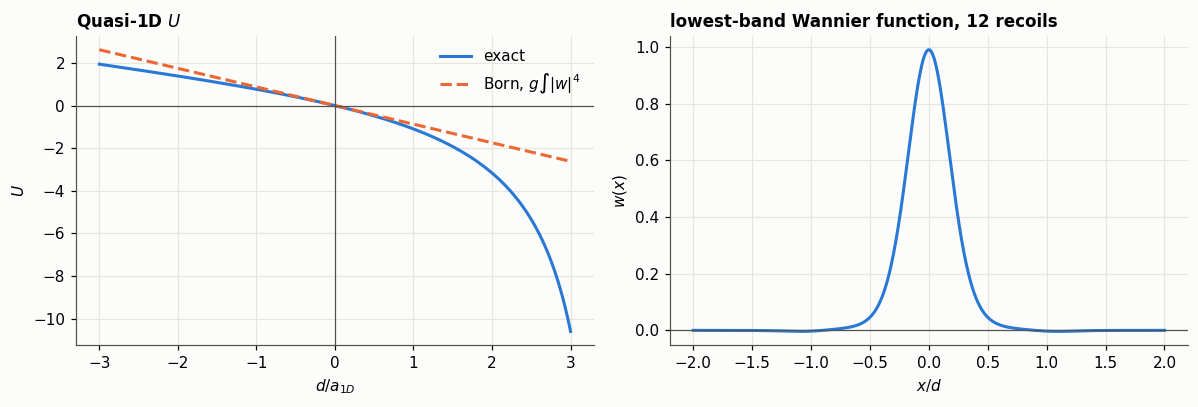

In [3]:
d_c, alpha, depth = np.pi, 1.0, 12.0
conv = UnitConverter(d_c, alpha)
omega_perp = (40.0 / V_REC) * conv.recoil_energy

exact = hubbard_u_quasi1d(depth=depth, omega_perp=omega_perp,
                          lattice_constant=d_c, alpha=alpha, conv_param=3)
born, quartic, norm = hubbard_u_wannier_1d(depth, omega_perp, d_c, alpha)
print(f"t = {exact.t:.6f} ({exact.t/conv.recoil_energy:.6f} E_rec)")
print(f"int|w|^4 = {quartic:.6f} (solver units), Wannier norm = {norm:.10f}")

x = np.linspace(-3, 3, 601) / d_c        # 1/a_1D in caller units
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.plot(x * d_c, exact(x), color=SERIES[0], label="exact")
ax1.plot(x * d_c, born(x), color=SERIES[1], ls="--", label=r"Born, $g\int|w|^4$")
ax1.axhline(0, color=INK2, lw=0.8); ax1.axvline(0, color=INK2, lw=0.8)
ax1.set_xlabel(r"$d/a_{1D}$"); ax1.set_ylabel(r"$U$"); ax1.legend()
ax1.set_title("Quasi-1D $U$")

wx = np.linspace(-2, 2, 801)
ax2.plot(wx, wannier_profile_1d(depth, wx * d_c, d_c), color=SERIES[0])
ax2.axhline(0, color=INK2, lw=0.8)
ax2.set_xlabel("$x/d$"); ax2.set_ylabel("$w(x)$")
ax2.set_title(f"lowest-band Wannier function, {depth:.0f} recoils")
fig.tight_layout(); plt.show()

### The Born limit, and how it improves with depth

The gap between the two is the physics the single-band picture drops: off-site
and inter-band processes. It must vanish with the coupling, and it must shrink as
the lattice deepens and the on-site wavefunction tightens. Both are checked here
— they are the cheapest available guard against a units error.

In [4]:
print(f"{'depth':>6} {'int|w|^4':>10} {'Born slope':>12} {'exact slope':>12} {'deviation':>11}")
prev = None
for dep in [8.0, 12.0, 16.0, 20.0, 25.0]:
    ex = hubbard_u_quasi1d(depth=dep, omega_perp=omega_perp, lattice_constant=d_c,
                           alpha=alpha, conv_param=3)
    bo, q, _ = hubbard_u_wannier_1d(dep, omega_perp, d_c, alpha)
    h = 1e-2 / d_c
    se = (float(ex(h)) - float(ex(-h))) / (2 * h)
    sb = (float(bo(h)) - float(bo(-h))) / (2 * h)
    dev = abs(se - sb) / abs(sb)
    flag = "" if prev is None else (" v" if dev < prev else " ^")
    prev = dev
    print(f"{dep:6.1f} {q:10.6f} {sb:12.6f} {se:12.6f} {dev:10.2%}{flag}")
print("\nthe deviation falls monotonically with depth, as it must")

 depth   int|w|^4   Born slope  exact slope   deviation


   8.0   1.895282    -2.413148    -2.504847      3.80%


  12.0   2.153064    -2.741366    -2.773045      1.16% v


  16.0   2.345497    -2.986379    -2.998999      0.42% v


  20.0   2.501447    -3.184941    -3.190467      0.17% v


  25.0   2.664179    -3.392138    -3.394299      0.06% v

the deviation falls monotonically with depth, as it must


## 3. Quasi-2D (separable square lattice)

Same idea in two dimensions, with a tight harmonic confinement along $z$. The
coupling is now parameterised by $\log(1/a_{\rm 2D})$; `log_a2d_inv_from_a3d`
converts from the 3D scattering length.

a_ho = 0.26591, E_rec(lattice) = 0.56250


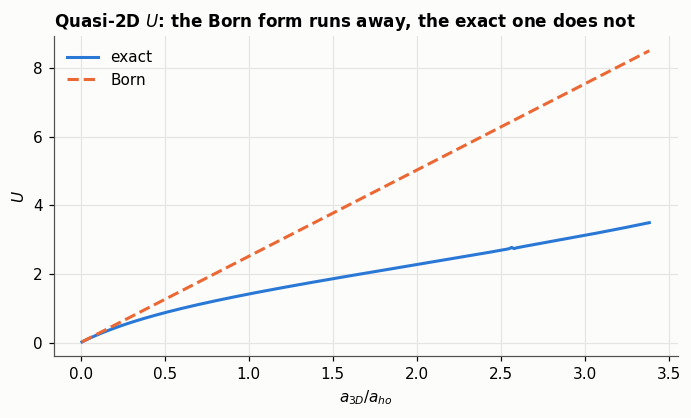

In [5]:
a_lat, alpha = 4 * np.pi / 3, 1.0
conv2 = UnitConverter(a_lat, alpha)
omega_z = 2 * np.sqrt(50 * 4.0)          # a 532 nm lattice, 50 recoils deep
a_ho = np.sqrt(2 / omega_z)
depth2 = 11.0

ex2 = hubbard_u_quasi2d(depth=depth2, omega_z=omega_z, lattice_constant=a_lat,
                        alpha=alpha, conv_param=2)
bo2, parts = hubbard_u_wannier_2d_square(depth2, omega_z, a_lat, alpha)
print(f"a_ho = {a_ho:.5f}, E_rec(lattice) = {conv2.recoil_energy:.5f}")

a3 = np.linspace(0.002, 0.9, 240)
L = np.asarray(log_a2d_inv_from_a3d(a3, omega_z, a_lat, alpha), dtype=float)
fig, ax = plt.subplots(figsize=(6.4, 3.9))
ax.plot(a3 / a_ho, [float(ex2(li)) for li in L], color=SERIES[0], label="exact")
ax.plot(a3 / a_ho, [float(bo2(a)) for a in a3], color=SERIES[1], ls="--", label="Born")
ax.set_xlabel(r"$a_{3D}/a_{ho}$"); ax.set_ylabel(r"$U$")
ax.set_title("Quasi-2D $U$: the Born form runs away, the exact one does not")
ax.legend(); fig.tight_layout(); plt.show()

## 4. Non-separable lattices

A honeycomb, triangular or any other non-separable in-plane geometry cannot be
written as $V_x(x)+V_y(y)$, so it cannot be handed to `hubbard_u_quasi2d`.

The supported workaround is a **matched separable reference**: pick the square
lattice with the same site spacing, the same vertical confinement, and the same
on-site Wannier overlap $\int|w|^4$. Because the last of these is matched, the
reference's *Born* $U$ equals the real lattice's Born $U$ exactly, so the ratio
of exact to Born is a clean beyond-Born factor with the geometry divided out.

This is an approximation: it assumes the correction depends on the site only
through its on-site confinement, not through the lattice symmetry. Say so
wherever you use it.

In [6]:
# pretend this came from a honeycomb calculation
q_honeycomb = 0.25
d_ref = matched_square_depth_from_quartic(q_honeycomb, a_lat, alpha)
print(f"honeycomb int|w_A|^4 = {q_honeycomb}")
print(f"matched square depth = {d_ref:.4f} lattice recoils "
      f"(check: {wannier_quartic_2d_square(d_ref, a_lat):.6f})")
print(f"implied on-site hbar*omega = {site_trap_frequency(d_ref, a_lat, alpha):.4f}")

ex_ref = hubbard_u_quasi2d(depth=d_ref, omega_z=omega_z, lattice_constant=a_lat,
                           alpha=alpha, conv_param=2)
bo_ref, _ = hubbard_u_wannier_2d_square(d_ref, omega_z, a_lat, alpha)

print(f"\n{'a_3D/a_ho':>10} {'U_exact':>11} {'U_Born':>11} {'ratio':>9}")
for a in [0.01, 0.05, 0.2, 0.5, 1.0, 2.0]:
    aa = a * a_ho
    li = float(log_a2d_inv_from_a3d(aa, omega_z, a_lat, alpha))
    ue, ub = float(ex_ref(li)), float(bo_ref(aa))
    print(f"{a:10.2f} {ue:11.5f} {ub:11.5f} {ue/ub:9.4f}")
print("\nthe ratio -> 1 at weak coupling and falls well below it once "
      "a_3D ~ a_ho")

honeycomb int|w_A|^4 = 0.25


matched square depth = 10.9638 lattice recoils (check: 0.250000)
implied on-site hbar*omega = 3.7251



 a_3D/a_ho     U_exact      U_Born     ratio
      0.01     0.02468     0.02507    0.9845
      0.05     0.11875     0.12533    0.9475
      0.20     0.41913     0.50133    0.8360
      0.50     0.86792     1.25331    0.6925
      1.00     1.41149     2.50663    0.5631
      2.00     2.26720     5.01326    0.4522

the ratio -> 1 at weak coupling and falls well below it once a_3D ~ a_ho


## 5. Convergence

`conv_param` bundles every cutoff (centre-of-mass and relative-momentum
truncations, quadrature orders, the transverse mode-sum limit). `p_on_shell` is
the relative quasi-momentum at which the amplitudes are matched and is formally a
limit to zero.

Away from the two-body resonances $U$ is stable at the percent level. **Near**
one it is not — the resonance positions themselves move with the cutoffs — so
quote $U$ near a resonance only with an error bar obtained by varying both knobs.

In [7]:
probe = np.array([-3.0, -1.0, 1.0, 3.0]) / d_c
print("U at fixed d/a_1D, varying conv_param (quasi-1D, 12 recoils)")
print("conv  " + "".join(f"{float(x*d_c):>12.1f}" for x in probe))
rows = []
for cp in [1, 2, 3, 4]:
    r = hubbard_u_quasi1d(depth=12.0, omega_perp=omega_perp, lattice_constant=d_c,
                          alpha=alpha, conv_param=cp)
    v = np.asarray(r(probe), dtype=float)
    rows.append(v)
    print(f"{cp:>4}  " + "".join(f"{x:>12.5f}" for x in v))
rows = np.array(rows)
spread = (rows.max(axis=0) - rows.min(axis=0)) / np.abs(rows.mean(axis=0))
print("\nrelative spread across conv_param 1-4:",
      "  ".join(f"{s:.2%}" for s in spread))

U at fixed d/a_1D, varying conv_param (quasi-1D, 12 recoils)
conv          -3.0        -1.0         1.0         3.0


   1       1.94058     0.76443    -1.09757   -10.61955


   2       1.94417     0.76486    -1.09674   -10.51392


   3       1.94149     0.76437    -1.09779   -10.59312


   4       1.91987     0.76094    -1.10496   -11.28637

relative spread across conv_param 1-4: 1.25%  0.51%  0.75%  7.18%
